https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Modelacion3/CalculosCRTBP.ipynb

In [1]:
!pip install -Uq pymcel celluloid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.4 MB/s eta 0:00:00


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
Epochs = {'start': '2026-06-16', 'stop': '2026-07-16', 'step': '1d'}

ids = ["699","606","607"]

cuerpos = {
    "Saturno": "699",
    "Titan": "606",
    "Hiperion": "607"
}

all_tablas = {}
all_tiempo_jd = {}
all_vector_estado = {}

for name, body_id in cuerpos.items():
  tabla_body, tiempo_jd_body, vector_estado_body = pc.consulta_horizons(
      id=body_id,
      location='@6',
      epochs=Epochs,
      datos='vectors',
  )

  all_tablas[name] = tabla_body
  all_tiempo_jd[name] = tiempo_jd_body
  all_vector_estado[name] = vector_estado_body

tabla = all_tablas
tiempo_jd = all_tiempo_jd
vector_estado = all_vector_estado

Definimos las unidades canónicas:

$$U_M = M = m_1+m_2$$

$$U_L = a$$

Por la ley armónica $n =\sqrt{\frac{\mu}{a^3}} = 1$

Se escoje $\alpha = \mu_2 = Gm_2$

Entonces $\mu_1 = 1-\alpha$

In [4]:
# Masas aproximadas (kg) - Asegúrate de usar valores precisos si los tienes en pc.constantes
m_saturno = 5.683e26
m_titan = 1.345e23

# Factor de conversión para simplificar la fórmula
# Usamos la masa total como denominador
M_total = m_saturno + m_titan

# Extraer los arrays de estado (asegúrate de que tengan la misma longitud de tiempo)
# Asumimos que 'tiempo_jd' está sincronizado para todos
t_keys = list(tiempo_jd.keys())
n_steps = len(tiempo_jd[t_keys[0]])

# Inicializar arrays para el baricentro Sat-Titan
r_cm = np.zeros((n_steps, 3))
v_cm = np.zeros((n_steps, 3))

for i in range(n_steps):
    # Posiciones y velocidades de Saturno y Titan en el paso i
    # Nota: Verifica el orden de tus vectores [x,y,z,vx,vy,vz] o si están separados
    # Asumiendo que vector_estado[name][i] devuelve [x,y,z,vx,vy,vz]

    # CORRECCIÓN: Usar .iloc[i] para acceder a las filas por posición
    state_sat = all_vector_estado["Saturno"].iloc[i]
    state_tit = all_vector_estado["Titan"].iloc[i]

    r_sat = state_sat[:3]
    v_sat = state_sat[3:]

    r_tit = state_tit[:3]
    v_tit = state_tit[3:]

    # Calcular Baricentro
    r_cm[i] = (m_saturno * r_sat + m_titan * r_tit) / M_total
    v_cm[i] = (m_saturno * v_sat + m_titan * v_tit) / M_total

# Ahora, para obtener las posiciones RELATIVAS al baricentro Sat-Titan:
vector_estado_relativo = {}

for name, body_id in cuerpos.items():
    # all_vector_estado[name] es un DataFrame, necesitamos convertirlo a numpy array para indexar por 'i' como antes
    states_originales_np = all_vector_estado[name].to_numpy()
    states_relativos = []

    for i in range(n_steps):
        # CORRECCIÓN: Ahora states_originales_np ya es un array de numpy
        r_body = states_originales_np[i][:3]
        v_body = states_originales_np[i][3:]

        # Restar el movimiento del baricentro
        r_rel = r_body - r_cm[i]
        v_rel = v_body - v_cm[i]

        states_relativos.append(np.concatenate([r_rel, v_rel]))

    vector_estado_relativo[name] = np.array(states_relativos)

# Ahora 'vector_estado_relativo' contiene las posiciones y velocidades
# referidas al centro de masa de Saturno-Titán.

In [6]:
G = pc.constantes.G
m1 = pc.constantes.mu_saturn/G    # Masa de saturno
m2 = 1.345e23                     # Masa de titán
m3 = 5.686e18                     # Masa de hiperion

a = 1.2218e9

# Definimos unidades canonicas
U_M = m1+m2
U_L = a
U_T = np.sqrt(U_L**3/(G*U_M))
U_V = U_L/U_T

mu2 = m2*G / (G*U_M)
alpha = mu2
mu1 = 1-alpha

In [7]:
# Funcion de transformacion a unidades canonicas
def SistemaInternacional2Canonicas(estado_si):
    Y_s_Canonico = {}
    for id, df_SI in estado_si.items():
        df_Canonico = df_SI.copy()

        df_Canonico[['x', 'y', 'z']] = df_SI[['x', 'y', 'z']] / U_L

        df_Canonico[['vx', 'vy', 'vz']] = df_SI[['vx', 'vy', 'vz']] / U_V

        Y_s_Canonico[id] = df_Canonico
    return Y_s_Canonico

In [8]:
vector_estado_canonico = SistemaInternacional2Canonicas(vector_estado)

# Ecuaciones del CRTBP

In [9]:
def edm_crtbp(t, Ys, alpha):
  x, y, z, vx, vy, vz = Ys

  # Variables auxiliares
  x1 = -alpha # Posición del cuerpo 1
  x2 = 1 - alpha
  r1 = np.sqrt((x-x1)**2 + y**2 + z**2)
  r2 = np.sqrt((x-x2)**2 + y**2 + z**2)

  # Ecuaciones
  dx_dt = vx
  dy_dt = vy
  dz_dt = vz
  dvx_dt = +2*vy + x  - (1 - alpha) / r1**3 * (x - x1) - alpha / r2**3 * (x - x2)
  dvy_dt = -2*vx + y  - (1 - alpha) / r1**3 * y - alpha / r2**3 * y
  dvz_dt =            - (1 - alpha) / r1**3 * z - alpha / r2**3 * z

  return [dx_dt, dy_dt, dz_dt, dvx_dt, dvy_dt, dvz_dt]

In [10]:
from scipy.integrate import solve_ivp

In [19]:
import numpy as np

def transformar_a_CRTBP_frame(estado_si, m1_si, m2_si, U_L, U_V):
    """
    Transforma el vector de estado inicial de una partícula (ej. Hiperión) desde
    el Sistema Internacional (SI) al sistema de referencia rotatorio baricéntrico
    canónico para el Problema Circular Restringido de Tres Cuerpos (CRTBP).

    En este sistema:
    - El origen es el baricentro de m1 y m2.
    - El eje X apunta de m1 a m2.
    - Las unidades son canónicas (G=1, Masa Total=1, Distancia=1).

    Parámetros:
    -----------
    estado_si : dict of DataFrames or Arrays
        Diccionario con claves 'Saturno', 'Titan', 'Hiperion' (o similares).
        Cada valor debe ser un array o DataFrame con columnas/índices
        ['x', 'y', 'z', 'vx', 'vy', 'vz'] o accesible por índices [0:3] y [3:6].

    m1_si : float
        Masa del cuerpo primario 1 (ej. Saturno) en kg.

    m2_si : float
        Masa del cuerpo primario 2 (ej. Titán) en kg.

    U_L : float
        Factor de conversión de longitud (metros -> unidad canónica).
        Usualmente U_L = a (distancia entre cuerpos).

    U_V : float
        Factor de conversión de velocidad (m/s -> unidad canónica).
        Usualmente U_V = U_L / U_T.

    Retorna:
    --------
    Y_canonico : np.array
        Vector de estado [x, y, z, vx, vy, vz] en unidades canónicas rotantes.
    """

    # 1. Extraer vectores de estado en SI (asumiendo estructura compatible)
    # Nota: Ajustar el acceso a datos según si son DataFrames o Arrays
    def get_vec(name):
        data = estado_si[name]
        if hasattr(data, 'values'): # Si es DataFrame
            return data[['x', 'y', 'z', 'vx', 'vy', 'vz']].iloc[0].to_numpy()
        else: # Si es array/lista
            return np.array(data[0]) # Asumiendo que es el primer instante

    r1_si = get_vec('Saturno')[:3]
    v1_si = get_vec('Saturno')[3:]

    r2_si = get_vec('Titan')[:3]
    v2_si = get_vec('Titan')[3:]

    r3_si = get_vec('Hiperion')[:3]
    v3_si = get_vec('Hiperion')[3:]

    # 2. Calcular el Baricentro del sistema binario (m1 + m2)
    M_total = m1_si + m2_si

    r_cm_si = (m1_si * r1_si + m2_si * r2_si) / M_total
    v_cm_si = (m1_si * v1_si + m2_si * v2_si) / M_total

    # 3. Trasladar al sistema centrado en el baricentro (pero aún inercial y sin rotar)
    r_rel_si = r3_si - r_cm_si
    v_rel_si = v3_si - v_cm_si

    # 4. Determinar el ángulo de rotación theta
    # El vector que define el eje X del sistema rotante es r12 (de m1 a m2)
    r12_si = r2_si - r1_si

    # Calculamos el ángulo que forma r12 con el eje X inercial
    # atan2(y, x) nos da el ángulo en el plano XY
    theta = np.arctan2(r12_si[1], r12_si[0])

    # 5. Construir la Matriz de Rotación R(-theta)
    # Queremos rotar el sistema inercial para que r12 quede sobre el eje X.
    # Esto equivale a rotar los vectores por -theta.
    cos_t = np.cos(-theta)
    sin_t = np.sin(-theta)

    R = np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0],
        [0,      0,     1]
    ])

    # 6. Aplicar la rotación a la posición relativa
    # r_rot = R * r_rel
    r_rot_si = np.dot(R, r_rel_si)

    # 7. Aplicar la transformación de velocidad completa
    # v_rot = R * (v_rel - omega x r_rel)
    # En unidades SI, la velocidad angular omega del sistema binario es n.
    # Sin embargo, es más fácil calcular esto en unidades canónicas directamente
    # o usar el hecho de que en el marco rotante CANÓNICO, omega = 1 (vector k).

    # Estrategia híbrida: Convertimos posiciones y velocidades a canónicas PRIMERO,
    # luego aplicamos la rotación y la corrección de velocidad rotacional.

    # Escalar a Unidades Canónicas (todavía en marco inercial alineado con baricentro)
    r_can_inertial = r_rel_si / U_L
    v_can_inertial = v_rel_si / U_V

    # Ahora aplicamos la rotación a las cantidades canónicas
    r_can_rot = np.dot(R, r_can_inertial)

    # Corrección de velocidad por rotación del marco:
    # v_rot = v_inertial_rotated - (omega_canonical x r_rot)
    # En unidades canónicas del CRTBP, la velocidad angular omega es 1 en dirección Z.
    omega_can = np.array([0, 0, 1])

    # Producto cruz omega x r
    omega_cross_r = np.cross(omega_can, r_can_rot)

    # Rotamos la velocidad inercial canónica
    v_can_inertial_rot = np.dot(R, v_can_inertial)

    # Velocidad final en el marco rotante canónico
    v_can_rot = v_can_inertial_rot - omega_cross_r

    # 8. Ensamblar el vector de estado final
    Y_canonico = np.concatenate((r_can_rot, v_can_rot))

    return Y_canonico

In [20]:
# Usar la función para obtener las condiciones iniciales correctas para Hiperión en el marco CRTBP
x, y, z, vx, vy, vz = transformar_a_CRTBP_frame(
    vector_estado, m1, m2, U_L, U_V
)

In [21]:
ts = np.linspace(0, 30, 1000)
Ys = [x, y, z, vx, vy, vz]
sol = solve_ivp(
    edm_crtbp,
    [ts[0], ts[-1]],
    Ys,
    t_eval=ts,
    args=(alpha,),
    method='Radau'
)
xs = sol.y[0]
ys = sol.y[1]
zs = sol.y[2]
vxs = sol.y[3]
vys = sol.y[4]
vzs = sol.y[5]

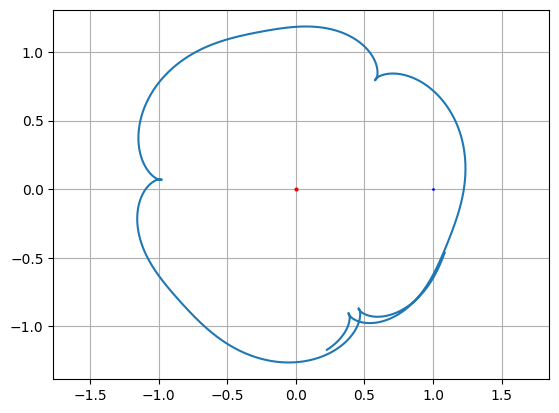

In [22]:
plt.plot(xs, ys)
plt.plot(-alpha, 0, 'ro', ms=2)
plt.plot(1-alpha, 0, 'bo', ms=1)

plt.axis('equal')
plt.grid()

In [18]:
Ys

[np.float64(1.0852318428911008),
 np.float64(-0.46271532539084137),
 np.float64(-0.5221406362391335),
 np.float64(-0.11900370869196303),
 np.float64(-0.33182668724097014),
 np.float64(0.2018603988797804)]

In [23]:
Ys

[np.float64(1.0852318428911008),
 np.float64(-0.46271532539084137),
 np.float64(-0.5221406362391335),
 np.float64(-0.11900370869196308),
 np.float64(-0.3318266872409701),
 np.float64(0.2018603988797804)]

In [ ]:
xs_hiperion = vector_estado_canonico["Hiperion"][["x"]].to_numpy()
ys_hiperion = vector_estado_canonico["Hiperion"][["y"]].to_numpy()
zs_hiperion = vector_estado_canonico["Hiperion"][["z"]].to_numpy()


xs_saturno = vector_estado_canonico["Saturno"][["x"]].to_numpy()
ys_saturno = vector_estado_canonico["Saturno"][["y"]].to_numpy()
zs_saturno = vector_estado_canonico["Saturno"][["z"]].to_numpy()


xs_titan = vector_estado_canonico["Titan"][["x"]].to_numpy()
ys_titan = vector_estado_canonico["Titan"][["y"]].to_numpy()
zs_titan = vector_estado_canonico["Titan"][["z"]].to_numpy()

plt.plot(xs_hiperion, ys_hiperion,"-r",lw=2)
plt.plot(xs_saturno, ys_saturno, "-m",lw=2)
plt.plot(xs_titan, ys_titan, "-k",lw=2)

plt.axis('equal')
plt.grid()